In [2]:
import h5py

file_path = "final_halo_catalog_void.h5"

with h5py.File(file_path, "r") as f:
    print("\n--- TOP LEVEL ---\n")
    for key in f.keys():
        obj = f[key]
        if isinstance(obj, h5py.Group):
            print(f"[GROUP] {key}")
        elif isinstance(obj, h5py.Dataset):
            print(f"[DATASET] {key}  shape={obj.shape}")


--- TOP LEVEL ---

[GROUP] halo_0
[GROUP] halo_10001
[GROUP] halo_10068
[GROUP] halo_1008
[GROUP] halo_10088
[GROUP] halo_1009
[GROUP] halo_10101
[GROUP] halo_1011
[GROUP] halo_1018
[GROUP] halo_102
[GROUP] halo_1020
[GROUP] halo_1026
[GROUP] halo_1033
[GROUP] halo_10344
[GROUP] halo_1039
[GROUP] halo_104
[GROUP] halo_10443
[GROUP] halo_1045
[GROUP] halo_10466
[GROUP] halo_1047
[GROUP] halo_1049
[GROUP] halo_1051
[GROUP] halo_1057
[GROUP] halo_1059
[GROUP] halo_1060
[GROUP] halo_10607
[GROUP] halo_107
[GROUP] halo_1072
[GROUP] halo_1073
[GROUP] halo_1079
[GROUP] halo_108
[GROUP] halo_1080
[GROUP] halo_1082
[GROUP] halo_1085
[GROUP] halo_1096
[GROUP] halo_110
[GROUP] halo_1101
[GROUP] halo_11027
[GROUP] halo_1105
[GROUP] halo_1107
[GROUP] halo_111
[GROUP] halo_1111
[GROUP] halo_11174
[GROUP] halo_1118
[GROUP] halo_1123
[GROUP] halo_1124
[GROUP] halo_1126
[GROUP] halo_1129
[GROUP] halo_11419
[GROUP] halo_1142
[GROUP] halo_1143
[GROUP] halo_1146
[GROUP] halo_1153
[GROUP] halo_1156
[GROUP

In [4]:
file_path = "final_halo_catalog_void.h5"

with h5py.File(file_path, "r") as f:
    halo = f["halo_0"]
    print(list(halo.keys()))

['SED_flux', 'SED_flux_density', 'SED_flux_density_with_noise', 'SED_flux_with_noise', 'SED_wav_angstroms', 'SED_wav_angstroms_with_noise', 'SED_wav_microns', 'SED_wav_microns_with_noise', 'Salpeter_IMF_SFR', 'Salpeter_IMF_SFR_with_noise', 'UV_continuum_slope', 'UV_continuum_slope_error', 'UV_continuum_slope_error_with_noise', 'UV_continuum_slope_with_noise', 'absolute_magnitude_UV', 'absolute_magnitude_UV_with_noise', 'angular_momentum', 'apparent_magnitude', 'apparent_magnitude_with_noise', 'bh_particle_IDs', 'color_band', 'color_band_with_noise', 'emission_lines', 'gas_mass', 'half_light_rad', 'half_light_rad_with_noise', 'image', 'image_with_noise', 'pop2_metallicity_fraction', 'pop2_stellar_age', 'pop2_stellar_angular_momentum', 'pop2_stellar_masses', 'pop2_stellar_positions', 'pop2_stellar_velocities', 'pop3_stellar_masses', 'position', 'sersic_error', 'sersic_error_with_noise', 'sersic_index', 'sersic_index_with_noise', 'star_particle_IDs', 'surface_brightness', 'surface_brightn


Opening HDF5 file...

Top-level structure:
  Total entries: 717
  Number of halos: 716
  Example halos: ['halo_0', 'halo_10001', 'halo_10068', 'halo_1008', 'halo_10088']
  'units' group found (contains physical units)


Inspecting halo_0:

  SED_flux: shape=(100, 2500), dtype=float64
  SED_flux_density: shape=(100, 2500), dtype=float64
  SED_flux_density_with_noise: shape=(100, 2500), dtype=float64
  SED_flux_with_noise: shape=(100, 2500), dtype=float64
  SED_wav_angstroms: shape=(2500,), dtype=float64
  SED_wav_angstroms_with_noise: shape=(2500,), dtype=float64
  SED_wav_microns: shape=(2500,), dtype=float64
  SED_wav_microns_with_noise: shape=(2500,), dtype=float64
  Salpeter_IMF_SFR: shape=(100,), dtype=float64
  Salpeter_IMF_SFR_with_noise: shape=(100,), dtype=float64
  UV_continuum_slope: shape=(100,), dtype=float64
  UV_continuum_slope_error: shape=(100, 2), dtype=float64
  UV_continuum_slope_error_with_noise: shape=(100, 2), dtype=float64
  UV_continuum_slope_with_noise: shape=

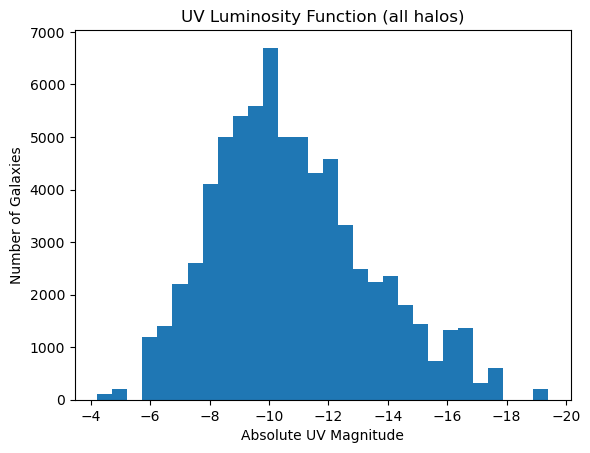

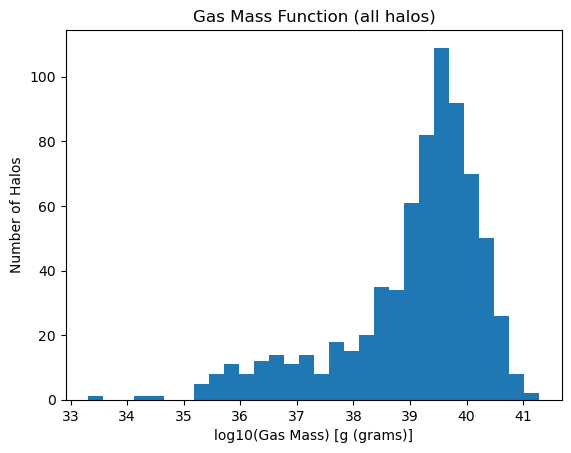


Done! You have successfully explored the file.


In [22]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

file_path = "final_halo_catalog_void.h5"

print("\nOpening HDF5 file...\n")

with h5py.File(file_path, "r") as f:

    # -------------------------------
    # Load units
    # -------------------------------
    units = f["units"].attrs if "units" in f else {}

    def get_unit(name):
        val = units.get(name, "")
        if isinstance(val, bytes):
            val = val.decode()

        if val in ["unitary", "dimensionless"]:
            return ""
        if val == "g":
            return "g (grams)"

        return val

    # -------------------------------
    # 1. Explain top-level structure
    # -------------------------------
    print("Top-level structure:")
    keys = list(f.keys())
    print(f"  Total entries: {len(keys)}")

    halo_names = [k for k in keys if k.startswith("halo_")]
    print(f"  Number of halos: {len(halo_names)}")
    print(f"  Example halos: {halo_names[:5]}")

    if "units" in keys:
        print("  'units' group found (contains physical units)\n")

    # -------------------------------
    # 2. Inspect one halo
    # -------------------------------
    example_halo = halo_names[0]
    halo = f[example_halo]

    print(f"\nInspecting {example_halo}:\n")

    for key in halo.keys():
        obj = halo[key]
        if isinstance(obj, h5py.Dataset):
            print(f"  {key}: shape={obj.shape}, dtype={obj.dtype}")



    # -------------------------------
    # 4. Collect data from ALL halos
    # -------------------------------
    print("\nCollecting data from ALL halos...\n")

    uv_mags = []
    gas_masses = []

    for i, name in enumerate(halo_names):

        # progress update every 100 halos
        if i % 100 == 0:
            print(f"  Processing halo {i+1}/{len(halo_names)}")

        h = f[name]

        if "absolute_magnitude_UV" in h:
            uv_mags.extend(h["absolute_magnitude_UV"][:])

        if "total_gas_mass" in h:
            gas_masses.append(h["total_gas_mass"][()])
        elif "gas_mass" in h:
            gas_masses.append(np.sum(h["gas_mass"][()]))

    print(f"\nFinished processing {len(halo_names)} halos.\n")

    uv_mags = np.array(uv_mags)
    gas_masses = np.array(gas_masses)

    # -------------------------------
    # 5. UV luminosity function
    # -------------------------------
    if len(uv_mags) > 0:
        plt.figure()
        plt.hist(uv_mags, bins=30)
        plt.xlabel("Absolute UV Magnitude")
        plt.ylabel("Number of Galaxies")
        plt.title("UV Luminosity Function (all halos)")
        plt.gca().invert_xaxis()
        plt.show()

    # -------------------------------
    # 6. Gas mass function
    # -------------------------------
    if len(gas_masses) > 0:
        plt.figure()
        plt.hist(np.log10(gas_masses), bins=30)
        plt.xlabel(f"log10(Gas Mass) [{get_unit(gas_unit_name)}]")
        plt.ylabel("Number of Halos")
        plt.title("Gas Mass Function (all halos)")
        plt.show()

print("\nDone! You have successfully explored the file.")

In [15]:
with h5py.File(file_path, "r") as f:

    # -------------------------------
    # Units inspection
    # -------------------------------
    if "units" in f:
        units_group = f["units"]

        print("\n--- Inspecting 'units' group ---\n")

        print("Keys inside units:", list(units_group.keys()))
        print("Attributes inside units:", list(units_group.attrs.keys()))

        # ✅ DEFINE units HERE (inside block)
        units = units_group.attrs

        print("\n--- Units ---\n")
        for key, val in units.items():
            if isinstance(val, bytes):
                val = val.decode()
            print(f"{key}: {val}")


--- Inspecting 'units' group ---

Keys inside units: []
Attributes inside units: ['SED_flux', 'SED_flux_density', 'SED_flux_density_with_noise', 'SED_flux_with_noise', 'SED_wav_angstroms', 'SED_wav_angstroms_with_noise', 'SED_wav_microns', 'SED_wav_microns_with_noise', 'SFE', 'Salpeter_IMF_SFR', 'Salpeter_IMF_SFR_with_noise', 'UV_continuum_slope', 'UV_continuum_slope_with_noise', 'absolute_magnitude_UV', 'absolute_magnitude_UV_with_noise', 'angular_momentum', 'apparent_magnitude', 'apparent_magnitude_with_noise', 'color_band', 'color_band_with_noise', 'emission_lines', 'fcov', 'fesc', 'gas_fraction', 'gas_mass', 'half_light_rad', 'half_light_rad_with_noise', 'half_stellar_mass_rad', 'image', 'image_with_noise', 'last_major_merger_halo_mass', 'pop2_SFR_100Myr', 'pop2_SFR_10Myr', 'pop2_metallicity_fraction', 'pop2_sSFR_100Myr', 'pop2_sSFR_10Myr', 'pop2_stellar_age', 'pop2_stellar_angular_momentum', 'pop2_stellar_masses', 'pop2_stellar_positions', 'pop2_stellar_velocities', 'pop3_stellar


Opening HDF5 file...


--- Inspecting 'units' group ---

Keys inside units: []
Attributes inside units: ['SED_flux', 'SED_flux_density', 'SED_flux_density_with_noise', 'SED_flux_with_noise', 'SED_wav_angstroms', 'SED_wav_angstroms_with_noise', 'SED_wav_microns', 'SED_wav_microns_with_noise', 'SFE', 'Salpeter_IMF_SFR', 'Salpeter_IMF_SFR_with_noise', 'UV_continuum_slope', 'UV_continuum_slope_with_noise', 'absolute_magnitude_UV', 'absolute_magnitude_UV_with_noise', 'angular_momentum', 'apparent_magnitude', 'apparent_magnitude_with_noise', 'color_band', 'color_band_with_noise', 'emission_lines', 'fcov', 'fesc', 'gas_fraction', 'gas_mass', 'half_light_rad', 'half_light_rad_with_noise', 'half_stellar_mass_rad', 'image', 'image_with_noise', 'last_major_merger_halo_mass', 'pop2_SFR_100Myr', 'pop2_SFR_10Myr', 'pop2_metallicity_fraction', 'pop2_sSFR_100Myr', 'pop2_sSFR_10Myr', 'pop2_stellar_age', 'pop2_stellar_angular_momentum', 'pop2_stellar_masses', 'pop2_stellar_positions', 'pop2_stellar_vel

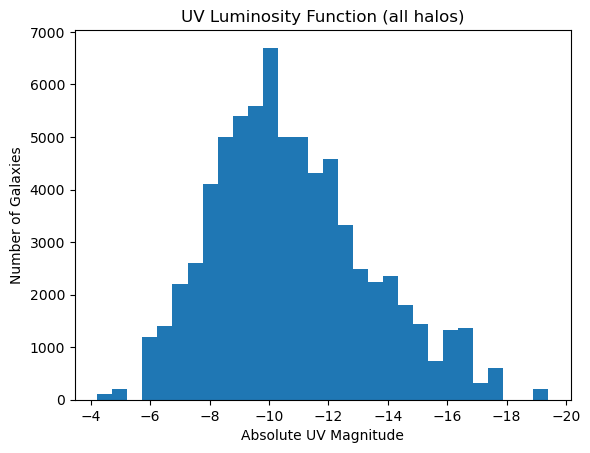

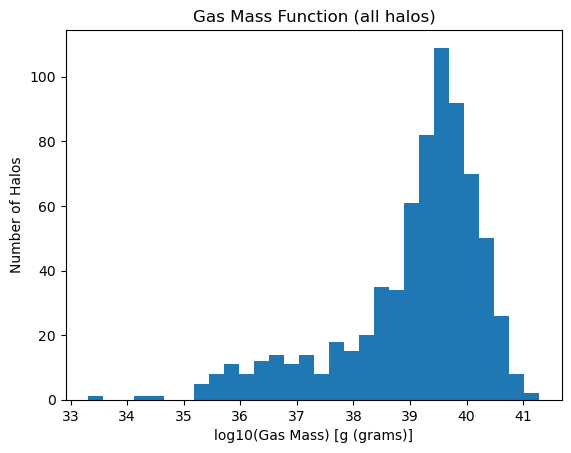


Done! You have successfully explored the file.


In [24]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

file_path = "final_halo_catalog_void.h5"

print("\nOpening HDF5 file...\n")

with h5py.File(file_path, "r") as f:

    # -------------------------------
    # 1. Explain top-level structure
    # -------------------------------
    print("Top-level structure:")
    keys = list(f.keys())
    print(f"  Total entries: {len(keys)}")

    halo_names = [k for k in keys if k.startswith("halo_")]
    print(f"  Number of halos: {len(halo_names)}")
    print(f"  Example halos: {halo_names[:5]}\n")

    # -------------------------------
    # 2. Inspect one halo (IMPROVED)
    # -------------------------------
    example_halo = halo_names[0]
    halo = f[example_halo]

    print(f"\n--- Detailed Field Summary for {example_halo} ---\n")
    print("Note:")
    print("  Shape → number of values in dataset")
    print("  Type  → data type")
    print("  Unit  → physical unit (if available)\n")

    print(f"{'Field':<35} {'Shape':<20} {'Type':<12} {'Unit'}")
    print("-" * 80)

    for key in sorted(halo.keys()):
        obj = halo[key]

        if isinstance(obj, h5py.Dataset):
            shape = str(obj.shape)
            dtype = str(obj.dtype)

            unit = get_unit(key)
            if unit == "":
                unit = "-"

            print(f"{key:<35} {shape:<20} {dtype:<12} {unit}")

    # -------------------------------
    # 3. Collect data from ALL halos
    # -------------------------------
    print("\nCollecting data from ALL halos...\n")

    uv_mags = []
    gas_masses = []

    # default in case no halos have gas
    gas_unit_name = "total_gas_mass"

    for i, name in enumerate(halo_names):

        if i % 100 == 0:
            print(f"  Processing halo {i+1}/{len(halo_names)}")

        h = f[name]

        if "absolute_magnitude_UV" in h:
            uv_mags.extend(h["absolute_magnitude_UV"][:])

        if "total_gas_mass" in h:
            gas_masses.append(h["total_gas_mass"][()])
            gas_unit_name = "total_gas_mass"
        elif "gas_mass" in h:
            gas_masses.append(np.sum(h["gas_mass"][()]))
            gas_unit_name = "gas_mass"

    print(f"\nFinished processing {len(halo_names)} halos.\n")

    uv_mags = np.array(uv_mags)
    gas_masses = np.array(gas_masses)

    # -------------------------------
    # 4. UV luminosity function
    # -------------------------------
    if len(uv_mags) > 0:
        plt.figure()
        plt.hist(uv_mags, bins=30)
        plt.xlabel("Absolute UV Magnitude")
        plt.ylabel("Number of Galaxies")
        plt.title("UV Luminosity Function (all halos)")
        plt.gca().invert_xaxis()
        plt.show()

    # -------------------------------
    # 5. Gas mass function
    # -------------------------------
    if len(gas_masses) > 0:
        plt.figure()
        plt.hist(np.log10(gas_masses), bins=30)
        plt.xlabel(f"log10(Gas Mass) [{get_unit(gas_unit_name)}]")
        plt.ylabel("Number of Halos")
        plt.title("Gas Mass Function (all halos)")
        plt.show()

print("\nDone! You have successfully explored the file.")


Opening HDF5 file...

Top-level structure:
  Total entries: 717
  Number of halos: 716
  Example halos: ['halo_0', 'halo_10001', 'halo_10068', 'halo_1008', 'halo_10088']
  Other entries: ['units']
    → 'units' contains the physical units for each dataset

(Set PRINT_ALL_HALO_NAMES = True to list the names of all 716 halos)


--- Field Summary (from halo_0) ---

Note:
  Shape → number of values in dataset
  Type  → data type
  Unit  → physical unit (if available)

Field                               Shape                Type         Unit
--------------------------------------------------------------------------------
SED_flux                            (100, 2500)          float64      mJy
SED_flux_density                    (100, 2500)          float64      erg / (cm2 micron s)
SED_flux_density_with_noise         (100, 2500)          float64      erg / (cm2 micron s)
SED_flux_with_noise                 (100, 2500)          float64      mJy
SED_wav_angstroms                   (2500,) 

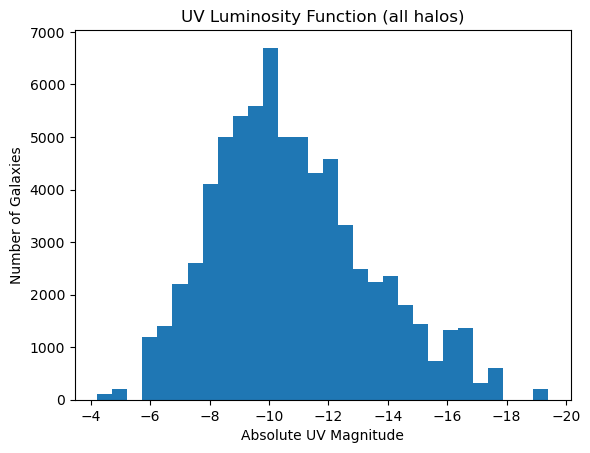

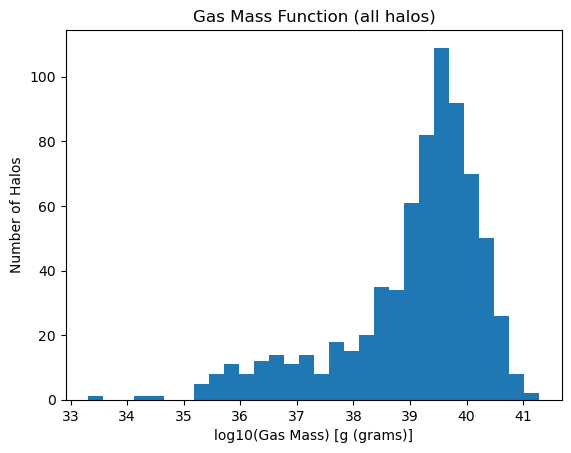


Done! You have successfully explored the file.


In [27]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

file_path = "final_halo_catalog_void.h5"

# 🔹 Toggles
PRINT_ALL_HALOS = False          # deep inspect every halo (very long)
PRINT_ALL_HALO_NAMES = False     # print only halo names (safe)

print("\nOpening HDF5 file...\n")

with h5py.File(file_path, "r") as f:

    # -------------------------------
    # 0. Units loading
    # -------------------------------
    units = f["units"].attrs if "units" in f else {}

    def get_unit(name):
        val = units.get(name, "")
        if isinstance(val, bytes):
            val = val.decode()

        if val in ["unitary", "dimensionless"]:
            return ""
        if val == "g":
            return "g (grams)"

        return val

    # -------------------------------
    # 1. Top-level structure
    # -------------------------------
    keys = list(f.keys())

    halo_names = [k for k in keys if k.startswith("halo_")]
    other_keys = [k for k in keys if not k.startswith("halo_")]

    print("Top-level structure:")
    print(f"  Total entries: {len(keys)}")
    print(f"  Number of halos: {len(halo_names)}")
    print(f"  Example halos: {halo_names[:5]}")

    if len(other_keys) > 0:
        print(f"  Other entries: {other_keys}")
        if "units" in other_keys:
            print("    → 'units' contains the physical units for each dataset")

    print()

    # -------------------------------
    # OPTIONAL: print ALL halo names
    # -------------------------------
    if PRINT_ALL_HALO_NAMES:
        print("\n--- Full list of halo names ---\n")

        for i, name in enumerate(halo_names):
            print(name)

            if i % 500 == 0 and i != 0:
                print(f"... printed {i} halos so far ...")

        print(f"\nTotal halos listed: {len(halo_names)}\n")
    else:
        print(f"(Set PRINT_ALL_HALO_NAMES = True to list the names of all {len(halo_names)} halos)\n")

    # -------------------------------
    # 2. Data dictionary (ONE halo)
    # -------------------------------
    example_halo = halo_names[0]
    halo = f[example_halo]

    print(f"\n--- Field Summary (from {example_halo}) ---\n")

    print("Note:")
    print("  Shape → number of values in dataset")
    print("  Type  → data type")
    print("  Unit  → physical unit (if available)\n")

    print(f"{'Field':<35} {'Shape':<20} {'Type':<12} {'Unit'}")
    print("-" * 80)

    for key in sorted(halo.keys()):
        obj = halo[key]

        if isinstance(obj, h5py.Dataset):
            shape = str(obj.shape)
            dtype = str(obj.dtype)

            unit = get_unit(key)
            if unit == "":
                unit = "-"

            print(f"{key:<35} {shape:<20} {dtype:<12} {unit}")

    # -------------------------------
    # 3. OPTIONAL: inspect ALL halos
    # -------------------------------
    if PRINT_ALL_HALOS:
        print("\n--- Inspecting ALL halos (very long output!) ---\n")

        for i, name in enumerate(halo_names):

            if i % 100 == 0:
                print(f"  Processing halo {i+1}/{len(halo_names)}")

            h = f[name]

            print(f"\n{name}:")
            for key in sorted(h.keys()):
                obj = h[key]
                if isinstance(obj, h5py.Dataset):
                    print(f"  {key}: shape={obj.shape}, dtype={obj.dtype}")
    else:
        print(f"\n(Set PRINT_ALL_HALOS = True to inspect full contents of all {len(halo_names)} halos)\n")

    # -------------------------------
    # 4. Collect data from ALL halos
    # -------------------------------
    print("Collecting data from ALL halos...\n")

    uv_mags = []
    gas_masses = []
    gas_unit_name = "total_gas_mass"

    for i, name in enumerate(halo_names):

        if i % 100 == 0:
            print(f"  Processing halo {i+1}/{len(halo_names)}")

        h = f[name]

        if "absolute_magnitude_UV" in h:
            uv_mags.extend(h["absolute_magnitude_UV"][:])

        if "total_gas_mass" in h:
            gas_masses.append(h["total_gas_mass"][()])
            gas_unit_name = "total_gas_mass"
        elif "gas_mass" in h:
            gas_masses.append(np.sum(h["gas_mass"][()]))
            gas_unit_name = "gas_mass"

    print(f"\nFinished processing {len(halo_names)} halos.\n")

    uv_mags = np.array(uv_mags)
    gas_masses = np.array(gas_masses)

    # -------------------------------
    # 5. UV luminosity function
    # -------------------------------
    if len(uv_mags) > 0:
        plt.figure()
        plt.hist(uv_mags, bins=30)
        plt.xlabel("Absolute UV Magnitude")
        plt.ylabel("Number of Galaxies")
        plt.title("UV Luminosity Function (all halos)")
        plt.gca().invert_xaxis()
        plt.show()

    # -------------------------------
    # 6. Gas mass function
    # -------------------------------
    if len(gas_masses) > 0:
        plt.figure()
        plt.hist(np.log10(gas_masses), bins=30)
        plt.xlabel(f"log10(Gas Mass) [{get_unit(gas_unit_name)}]")
        plt.ylabel("Number of Halos")
        plt.title("Gas Mass Function (all halos)")
        plt.show()

print("\nDone! You have successfully explored the file.")


Opening HDF5 file...

Top-level structure:
  Total entries: 717
  Number of halos: 716
  Example halos: ['halo_0', 'halo_10001', 'halo_10068', 'halo_1008', 'halo_10088']
  Other entries: ['units']
    → 'units' contains the physical units for each dataset

(Set PRINT_ALL_HALO_NAMES = True to list all 716 halos)


--- Field Summary (from halo_0) ---

Note:
  Shape → number of values in dataset
  Type  → data type
  Unit  → physical unit (if available)

Field                               Shape                Type         Unit
--------------------------------------------------------------------------------
SED_flux                            (100, 2500)          float64      mJy
SED_flux_density                    (100, 2500)          float64      erg / (cm2 micron s)
SED_flux_density_with_noise         (100, 2500)          float64      erg / (cm2 micron s)
SED_flux_with_noise                 (100, 2500)          float64      mJy
SED_wav_angstroms                   (2500,)              

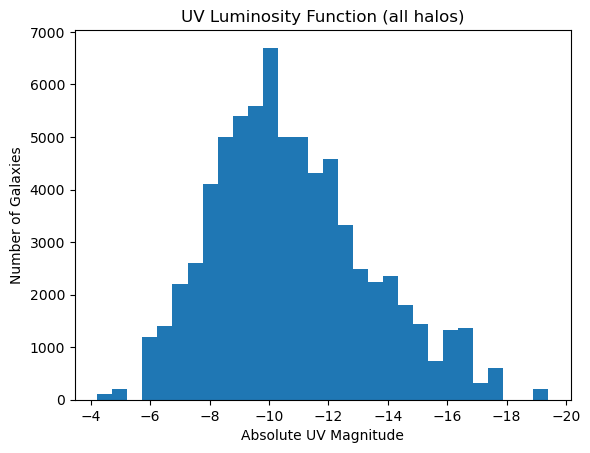

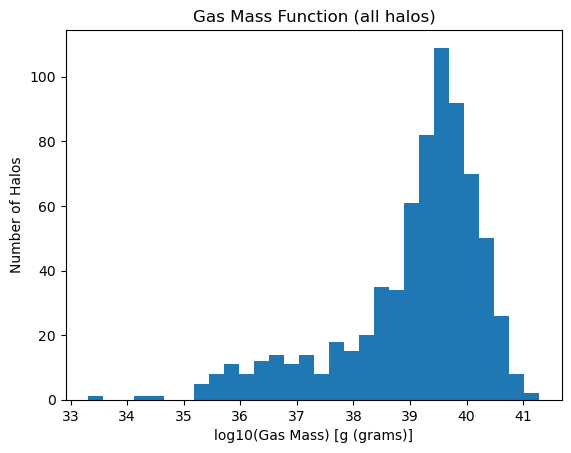


Done! You have successfully explored the file.


In [29]:
import h5py
import numpy as np
import matplotlib.pyplot as plt


# UPDATE PATH: This is the path to your HDF5 file
file_path = "final_halo_catalog_void.h5"

# USER TOGGLES
PRINT_ALL_HALO_NAMES = False     # prints just the names of halos (long)
PRINT_ALL_HALOS = False          # prints EVERYTHING inside every halo (very long)


print("\nOpening HDF5 file...\n")

# Open the HDF5 file
with h5py.File(file_path, "r") as f:

 
    # 0. LOAD UNITS (metadata)
    # The file has a special "units" group that tells us what physical units each halo attribute uses
    units = f["units"].attrs if "units" in f else {}

    # Helper function: safely get unit for any dataset
    def get_unit(name):
        val = units.get(name, "")

        # decode bytes → string
        if isinstance(val, bytes):
            val = val.decode()

        # clean up less helpful labels
        if val in ["unitary", "dimensionless"]:
            return ""
        if val == "g":
            return "g (grams)"

        return val


    # 1. TOP-LEVEL STRUCTURE
 
    # The HDF5 file is like a dictionary:
    # f.keys() = everything at the top level

    keys = list(f.keys())

    # Separate halos from other groups (like "units")
    halo_names = [k for k in keys if k.startswith("halo_")]
    other_keys = [k for k in keys if not k.startswith("halo_")]

    print("Top-level structure:")
    print(f"  Total entries: {len(keys)}")
    print(f"  Number of halos: {len(halo_names)}")
    print(f"  Example halos: {halo_names[:5]}")

    if len(other_keys) > 0:
        print(f"  Other entries: {other_keys}")
        if "units" in other_keys:
            print("    → 'units' contains the physical units for each dataset")

    print()


    # OPTIONAL: print all halo names
    # This shows how many halos exist and what they are called
    if PRINT_ALL_HALO_NAMES:
        print("\n--- Full list of halo names ---\n")

        for i, name in enumerate(halo_names):
            print(name)

            # progress for very large files
            if i % 500 == 0 and i != 0:
                print(f"... printed {i} halos so far ...")

        print(f"\nTotal halos listed: {len(halo_names)}\n")
    else:
        print(f"(Set PRINT_ALL_HALO_NAMES = True to list all {len(halo_names)} halos)\n")


    # 2. ACCESSING A SINGLE HALO
    # Each halo is like a folder:
    # f["halo_0"] gives you everything inside that halo

    #access list made of halo names
    example_halo = halo_names[0]
    halo = f[example_halo]

    print(f"\n--- Field Summary (from {example_halo}) ---\n")

    print("Note:")
    print("  Shape → number of values in dataset")
    print("  Type  → data type")
    print("  Unit  → physical unit (if available)\n")

    print(f"{'Field':<35} {'Shape':<20} {'Type':<12} {'Unit'}")
    print("-" * 80)

    # Loop through everything inside ONE halo
    for key in sorted(halo.keys()):

        # Each entry is either a dataset (array) or group
        obj = halo[key]

        if isinstance(obj, h5py.Dataset):
            shape = str(obj.shape)
            dtype = str(obj.dtype)

            unit = get_unit(key)
            if unit == "":
                unit = "-"

            print(f"{key:<35} {shape:<20} {dtype:<12} {unit}")

            
    # OPTIONAL: inspect ALL halos deeply
    if PRINT_ALL_HALOS:
        print("\n--- Inspecting ALL halos (very long output!) ---\n")

        for i, name in enumerate(halo_names):

            if i % 100 == 0:
                print(f"  Processing halo {i+1}/{len(halo_names)}")

            h = f[name]

            print(f"\n{name}:")
            for key in sorted(h.keys()):
                obj = h[key]
                if isinstance(obj, h5py.Dataset):
                    print(f"  {key}: shape={obj.shape}, dtype={obj.dtype}")
    else:
        print(f"\n(Set PRINT_ALL_HALOS = True to inspect all {len(halo_names)} halos)\n")


    # 3. COLLECT DATA FROM ALL HALOS
    # This is the key idea:
    # We LOOP through halos and extract specific fields

    print("Collecting data from ALL halos...\n")

    uv_mags = []       # store UV brightness values
    gas_masses = []    # store halo gas masses

    gas_unit_name = "total_gas_mass"

    for i, name in enumerate(halo_names):

        # progress indicator
        if i % 100 == 0:
            print(f"  Processing halo {i+1}/{len(halo_names)}")

        h = f[name]

        # Access dataset inside halo:
        # h["absolute_magnitude_UV"]
        if "absolute_magnitude_UV" in h:
            uv_mags.extend(h["absolute_magnitude_UV"][:])

        # Some halos store total mass directly
        if "total_gas_mass" in h:
            gas_masses.append(h["total_gas_mass"][()])
            gas_unit_name = "total_gas_mass"

        # Others require summing particle data
        elif "gas_mass" in h:
            gas_masses.append(np.sum(h["gas_mass"][()]))
            gas_unit_name = "gas_mass"

    print(f"\nFinished processing {len(halo_names)} halos.\n")

    # Convert to numpy arrays for analysis
    uv_mags = np.array(uv_mags)
    gas_masses = np.array(gas_masses)


    # 4. EXAMPLE PLOTS

    # UV Luminosity Function
    if len(uv_mags) > 0:
        plt.figure()
        plt.hist(uv_mags, bins=30)
        plt.xlabel("Absolute UV Magnitude")
        plt.ylabel("Number of Galaxies")
        plt.title("UV Luminosity Function (all halos)")
        plt.gca().invert_xaxis()  # brighter = more negative
        plt.show()

    # Gas Mass Function
    if len(gas_masses) > 0:
        plt.figure()
        plt.hist(np.log10(gas_masses), bins=30)
        plt.xlabel(f"log10(Gas Mass) [{get_unit(gas_unit_name)}]")
        plt.ylabel("Number of Halos")
        plt.title("Gas Mass Function (all halos)")
        plt.show()

print("\nDone! You have successfully explored the file.")


Opening HDF5 file...

Top-level structure:
  Total entries: 1520
  Number of halos: 1519
  Example halos: ['halo_0', 'halo_1', 'halo_100', 'halo_1000', 'halo_1001']
  Other entries: ['units']
    → 'units' contains the physical units for each dataset

(Set PRINT_ALL_HALO_NAMES = True to list all 1519 halos)


--- Field Summary (from halo_0) ---

Note:
  Shape → number of values in dataset
  Type  → data type
  Unit  → physical unit (if available)

Field                               Shape                Type         Unit
--------------------------------------------------------------------------------
SED_flux                            (100, 2500)          float64      mJy
SED_flux_density                    (100, 2500)          float64      erg / (cm2 micron s)
SED_flux_density_with_noise         (100, 2500)          float64      erg / (cm2 micron s)
SED_flux_with_noise                 (100, 2500)          float64      mJy
SED_wav_angstroms                   (2500,)              floa

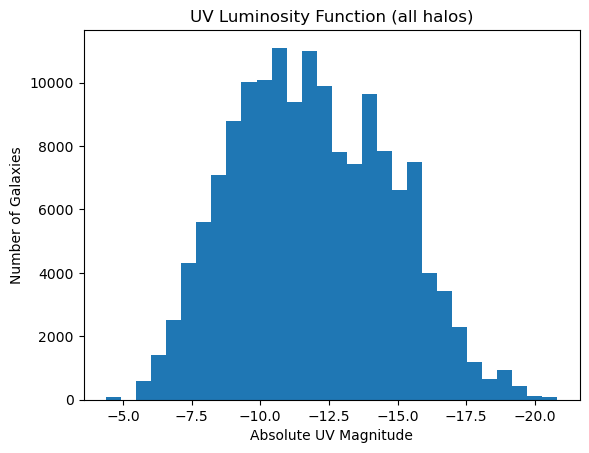

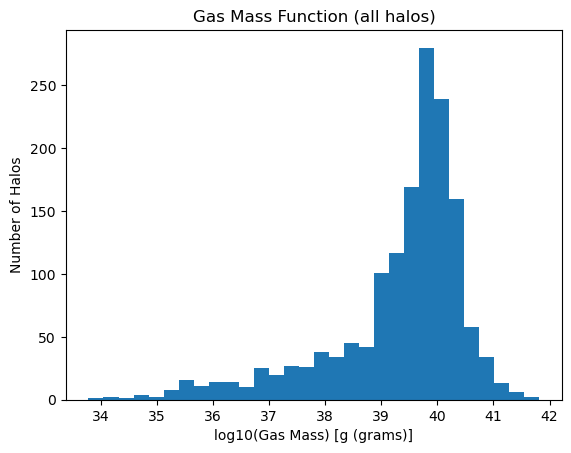


Done! You have successfully explored the file.


In [37]:
import h5py
import numpy as np
import matplotlib.pyplot as plt


# UPDATE PATH: This is the path to your HDF5 file
#change REGION section to be void, normal, or rarepeak
file_path = "final_halo_catalog_normal.h5"

# USER TOGGLES
PRINT_ALL_HALO_NAMES = False     # prints just the names of halos (long)
PRINT_ALL_HALOS = False          # prints EVERYTHING inside every halo (very long)


print("\nOpening HDF5 file...\n")

# Open the HDF5 file
with h5py.File(file_path, "r") as f:

 
    # 0. LOAD UNITS (metadata)
    # The file has a special "units" group that tells us what physical units each halo attribute uses
    units = f["units"].attrs if "units" in f else {}

    # Helper function: safely get unit for any dataset
    def get_unit(name):
        val = units.get(name, "")

        # decode bytes → string
        if isinstance(val, bytes):
            val = val.decode()

        # clean up less helpful labels
        if val in ["unitary", "dimensionless"]:
            return ""
        if val == "g":
            return "g (grams)"

        return val


    # 1. TOP-LEVEL STRUCTURE
 
    # The HDF5 file is like a dictionary:
    # f.keys() = everything at the top level

    keys = list(f.keys())

    # Separate halos from other groups (like "units")
    halo_names = [k for k in keys if k.startswith("halo_")]
    other_keys = [k for k in keys if not k.startswith("halo_")]

    print("Top-level structure:")
    print(f"  Total entries: {len(keys)}")
    print(f"  Number of halos: {len(halo_names)}")
    print(f"  Example halos: {halo_names[:5]}")

    if len(other_keys) > 0:
        print(f"  Other entries: {other_keys}")
        if "units" in other_keys:
            print("    → 'units' contains the physical units for each dataset")

    print()


    # OPTIONAL: print all halo names
    # This shows how many halos exist and what they are called
    if PRINT_ALL_HALO_NAMES:
        print("\n--- Full list of halo names ---\n")

        for i, name in enumerate(halo_names):
            print(name)

            # progress for very large files
            if i % 500 == 0 and i != 0:
                print(f"... printed {i} halos so far ...")

        print(f"\nTotal halos listed: {len(halo_names)}\n")
    else:
        print(f"(Set PRINT_ALL_HALO_NAMES = True to list all {len(halo_names)} halos)\n")


    # 2. ACCESSING A SINGLE HALO
    # Each halo is like a folder:
    # f["halo_0"] gives you everything inside that halo

    #access list made of halo names
    example_halo = halo_names[0]
    halo = f[example_halo]

    print(f"\n--- Field Summary (from {example_halo}) ---\n")

    print("Note:")
    print("  Shape → number of values in dataset")
    print("  Type  → data type")
    print("  Unit  → physical unit (if available)\n")

    print(f"{'Field':<35} {'Shape':<20} {'Type':<12} {'Unit'}")
    print("-" * 80)

    # Loop through everything inside ONE halo
    for key in sorted(halo.keys()):

        # Each entry is either a dataset (array) or group
        obj = halo[key]

        if isinstance(obj, h5py.Dataset):
            shape = str(obj.shape)
            dtype = str(obj.dtype)

            unit = get_unit(key)
            if unit == "":
                unit = "-"

            print(f"{key:<35} {shape:<20} {dtype:<12} {unit}")

            
    # OPTIONAL: inspect ALL halos deeply
    if PRINT_ALL_HALOS:
        print("\n--- Inspecting ALL halos (very long output!) ---\n")

        for i, name in enumerate(halo_names):

            if i % 100 == 0:
                print(f"  Processing halo {i+1}/{len(halo_names)}")

            h = f[name]

            print(f"\n{name}:")
            for key in sorted(h.keys()):
                obj = h[key]
                if isinstance(obj, h5py.Dataset):
                    print(f"  {key}: shape={obj.shape}, dtype={obj.dtype}")
    else:
        print(f"\n(Set PRINT_ALL_HALOS = True to inspect all {len(halo_names)} halos)\n")


    # 3. COLLECT DATA FROM ALL HALOS
    # This is the key idea:
    # We LOOP through halos and extract specific fields

    print("Collecting data from ALL halos...\n")

    uv_mags = []       # store UV brightness values
    gas_masses = []    # store halo gas masses

    gas_unit_name = "total_gas_mass"

    for i, name in enumerate(halo_names):

        # progress indicator
        if i % 100 == 0:
            print(f"  Processing halo {i+1}/{len(halo_names)}")

        h = f[name]

        # Access dataset inside halo:
        # h["absolute_magnitude_UV"]
        if "absolute_magnitude_UV" in h:
            uv_mags.extend(h["absolute_magnitude_UV"][:])

        # Some halos store total mass directly
        if "total_gas_mass" in h:
            gas_masses.append(h["total_gas_mass"][()])
            gas_unit_name = "total_gas_mass"

        # Others require summing particle data
        elif "gas_mass" in h:
            gas_masses.append(np.sum(h["gas_mass"][()]))
            gas_unit_name = "gas_mass"

    print(f"\nFinished processing {len(halo_names)} halos.\n")

    # Convert to numpy arrays for analysis
    uv_mags = np.array(uv_mags)
    gas_masses = np.array(gas_masses)


    # 4. EXAMPLE PLOTS

    # UV Luminosity Function
    if len(uv_mags) > 0:
        plt.figure()
        plt.hist(uv_mags, bins=30)
        plt.xlabel("Absolute UV Magnitude")
        plt.ylabel("Number of Galaxies")
        plt.title("UV Luminosity Function (all halos)")
        plt.gca().invert_xaxis()  # brighter = more negative
        plt.show()

    # Gas Mass Function
    if len(gas_masses) > 0:
        plt.figure()
        plt.hist(np.log10(gas_masses), bins=30)
        plt.xlabel(f"log10(Gas Mass) [{get_unit(gas_unit_name)}]")
        plt.ylabel("Number of Halos")
        plt.title("Gas Mass Function (all halos)")
        plt.show()

print("\nDone! You have successfully explored the file.")

In [2]:
import h5py

file_path = "final_halo_catalog_void.h5"

with h5py.File(file_path, "r") as f:

    # this shows everything in the file (all halos + units)
    f.keys()

    # pick one halo to look at
    f['halo_0']

    # this shows everything inside halo_0 (datasets)
    f['halo_0'].keys()

    # this shows all the attributes for halo_0
    f['halo_0'].attrs.keys()

    # this is how you open one attribute
    # this one is the redshift of the halo
    f['halo_0'].attrs['current_redshift']


Opening HDF5 file...

Top-level structure:
  Total entries: 1520
  Number of halos: 1519
  Example halos: ['halo_0', 'halo_1', 'halo_100', 'halo_1000', 'halo_1001']
  Other entries: ['units']
    → 'units' contains the physical units for each dataset

(Set PRINT_ALL_HALO_NAMES = True to list all 1519 halos)


--- Field Summary (from halo_0) ---

Note:
  Shape → number of values in dataset
  Type  → data type
  Unit  → physical unit (if available)

Field                               Shape                Type         Unit
--------------------------------------------------------------------------------
SED_flux                            (100, 2500)          float64      mJy
SED_flux_density                    (100, 2500)          float64      erg / (cm2 micron s)
SED_flux_density_with_noise         (100, 2500)          float64      erg / (cm2 micron s)
SED_flux_with_noise                 (100, 2500)          float64      mJy
SED_wav_angstroms                   (2500,)              floa

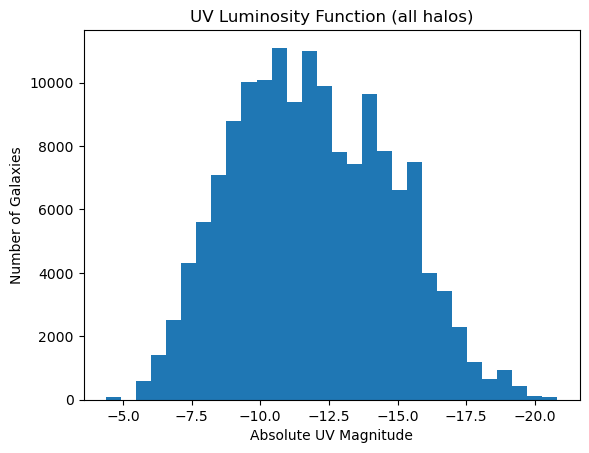

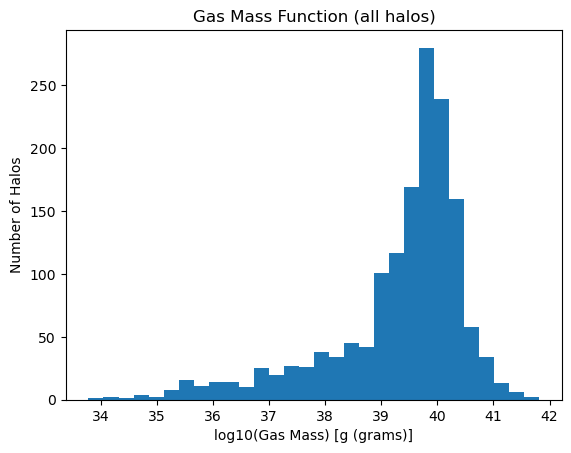


Done! You have successfully explored the file.


In [38]:
import h5py
import numpy as np
import matplotlib.pyplot as plt


# UPDATE PATH: This is the path to your HDF5 file
#change REGION section to be void, normal, or rarepeak
file_path = "final_halo_catalog_normal.h5"

# USER TOGGLES
PRINT_ALL_HALO_NAMES = False     # prints just the names of halos (long)
PRINT_ALL_HALOS = False          # prints EVERYTHING inside every halo (very long)


print("\nOpening HDF5 file...\n")

# Open the HDF5 file
with h5py.File(file_path, "r") as f:

 
    # 0. LOAD UNITS (metadata)
    # The file has a special "units" group that tells us what physical units each halo attribute uses
    units = f["units"].attrs if "units" in f else {}

    # Helper function: safely get unit for any dataset
    def get_unit(name):
        val = units.get(name, "")

        # decode bytes → string
        if isinstance(val, bytes):
            val = val.decode()

        # clean up less helpful labels
        if val in ["unitary", "dimensionless"]:
            return ""
        if val == "g":
            return "g (grams)"

        return val


    # 1. TOP-LEVEL STRUCTURE
 
    # The HDF5 file is like a dictionary:
    # f.keys() = everything at the top level

    keys = list(f.keys())

    # Separate halos from other groups (like "units")
    halo_names = [k for k in keys if k.startswith("halo_")]
    other_keys = [k for k in keys if not k.startswith("halo_")]

    print("Top-level structure:")
    print(f"  Total entries: {len(keys)}")
    print(f"  Number of halos: {len(halo_names)}")
    print(f"  Example halos: {halo_names[:5]}")

    if len(other_keys) > 0:
        print(f"  Other entries: {other_keys}")
        if "units" in other_keys:
            print("    → 'units' contains the physical units for each dataset")

    print()


    # OPTIONAL: print all halo names
    # This shows how many halos exist and what they are called
    if PRINT_ALL_HALO_NAMES:
        print("\n--- Full list of halo names ---\n")

        for i, name in enumerate(halo_names):
            print(name)

            # progress for very large files
            if i % 500 == 0 and i != 0:
                print(f"... printed {i} halos so far ...")

        print(f"\nTotal halos listed: {len(halo_names)}\n")
    else:
        print(f"(Set PRINT_ALL_HALO_NAMES = True to list all {len(halo_names)} halos)\n")


    # 2. ACCESSING A SINGLE HALO
    # Each halo is like a folder:
    # f["halo_0"] gives you everything inside that halo

    #access list made of halo names
    example_halo = halo_names[0]
    halo = f[example_halo]

    print(f"\n--- Field Summary (from {example_halo}) ---\n")

    print("Note:")
    print("  Shape → number of values in dataset")
    print("  Type  → data type")
    print("  Unit  → physical unit (if available)\n")

    print(f"{'Field':<35} {'Shape':<20} {'Type':<12} {'Unit'}")
    print("-" * 80)

    # Loop through everything inside ONE halo
    for key in sorted(halo.keys()):

        # Each entry is either a dataset (array) or group
        obj = halo[key]

        if isinstance(obj, h5py.Dataset):
            shape = str(obj.shape)
            dtype = str(obj.dtype)

            unit = get_unit(key)
            if unit == "":
                unit = "-"

            print(f"{key:<35} {shape:<20} {dtype:<12} {unit}")

            
    # OPTIONAL: inspect ALL halos deeply
    if PRINT_ALL_HALOS:
        print("\n--- Inspecting ALL halos (very long output!) ---\n")

        for i, name in enumerate(halo_names):

            if i % 100 == 0:
                print(f"  Processing halo {i+1}/{len(halo_names)}")

            h = f[name]

            print(f"\n{name}:")
            for key in sorted(h.keys()):
                obj = h[key]
                if isinstance(obj, h5py.Dataset):
                    print(f"  {key}: shape={obj.shape}, dtype={obj.dtype}")
    else:
        print(f"\n(Set PRINT_ALL_HALOS = True to inspect all {len(halo_names)} halos)\n")


    # 3. COLLECT DATA FROM ALL HALOS
    # This is the key idea:
    # We LOOP through halos and extract specific fields

    print("Collecting data from ALL halos...\n")

    uv_mags = []       # store UV brightness values
    gas_masses = []    # store halo gas masses

    gas_unit_name = "total_gas_mass"

    for i, name in enumerate(halo_names):

        # progress indicator
        if i % 100 == 0:
            print(f"  Processing halo {i+1}/{len(halo_names)}")

        h = f[name]

        # Access dataset inside halo:
        # h["absolute_magnitude_UV"]
        if "absolute_magnitude_UV" in h:
            uv_mags.extend(h["absolute_magnitude_UV"][:])

        # Some halos store total mass directly
        if "total_gas_mass" in h:
            gas_masses.append(h["total_gas_mass"][()])
            gas_unit_name = "total_gas_mass"

        # Others require summing particle data
        elif "gas_mass" in h:
            gas_masses.append(np.sum(h["gas_mass"][()]))
            gas_unit_name = "gas_mass"

    print(f"\nFinished processing {len(halo_names)} halos.\n")

    # Convert to numpy arrays for analysis
    uv_mags = np.array(uv_mags)
    gas_masses = np.array(gas_masses)


    # 4. EXAMPLE PLOTS

    # UV Luminosity Function
    if len(uv_mags) > 0:
        plt.figure()
        plt.hist(uv_mags, bins=30)
        plt.xlabel("Absolute UV Magnitude")
        plt.ylabel("Number of Galaxies")
        plt.title("UV Luminosity Function (all halos)")
        plt.gca().invert_xaxis()  # brighter = more negative
        plt.show()

    # Gas Mass Function
    if len(gas_masses) > 0:
        plt.figure()
        plt.hist(np.log10(gas_masses), bins=30)
        plt.xlabel(f"log10(Gas Mass) [{get_unit(gas_unit_name)}]")
        plt.ylabel("Number of Halos")
        plt.title("Gas Mass Function (all halos)")
        plt.show()

print("\nDone! You have successfully explored the file.")



Opening HDF5 file...

Top-level structure:
  Total entries: 1520
  Number of halos: 1519
  Example halos: ['halo_0', 'halo_1', 'halo_100', 'halo_1000', 'halo_1001']
  Other entries: ['units']
    → 'units' contains the physical units for each dataset

(Set PRINT_ALL_HALO_NAMES = True to list all 1519 halos)


--- Field Summary (from halo_0) ---

Note:
  Shape → number of values in dataset
  Type  → data type
  Unit  → physical unit (if available)

Field                               Shape                Type         Unit
--------------------------------------------------------------------------------
SED_flux                            (100, 2500)          float64      mJy
SED_flux_density                    (100, 2500)          float64      erg / (cm2 micron s)
SED_flux_density_with_noise         (100, 2500)          float64      erg / (cm2 micron s)
SED_flux_with_noise                 (100, 2500)          float64      mJy
SED_wav_angstroms                   (2500,)              floa

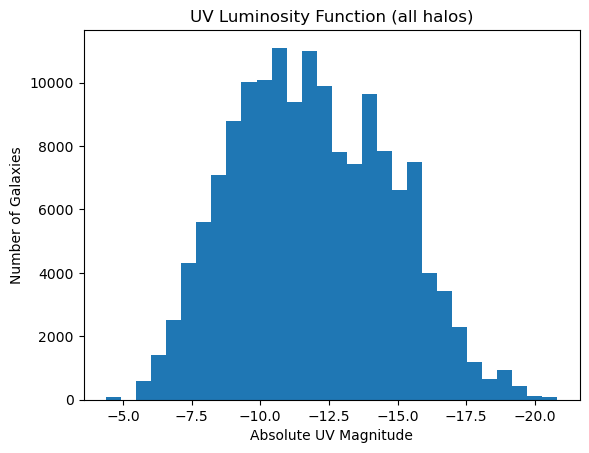

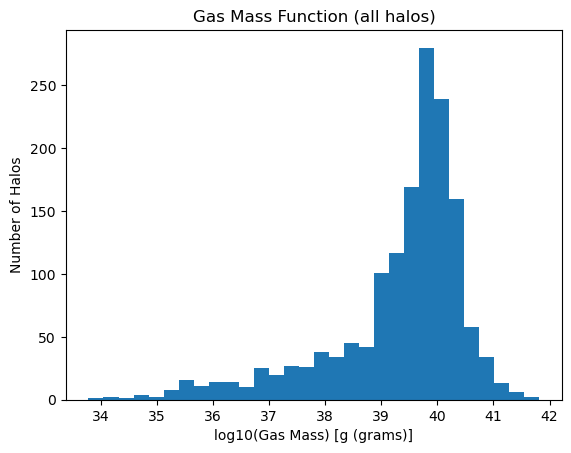


Done! You have successfully explored the file.


In [1]:

import h5py
import numpy as np
import matplotlib.pyplot as plt


# UPDATE PATH: This is the path to your HDF5 file
#change REGION section to be void, normal, or rarepeak
file_path = "final_halo_catalog_normal.h5"

# USER TOGGLES
PRINT_ALL_HALO_NAMES = False     # prints just the names of halos (long)
PRINT_ALL_HALOS = False          # prints EVERYTHING inside every halo (very long)


print("\nOpening HDF5 file...\n")

# Open the HDF5 file
with h5py.File(file_path, "r") as f:

 
    # 0. LOAD UNITS (metadata)
    # The file has a special "units" group that tells us what physical units each halo attribute uses
    units = f["units"].attrs if "units" in f else {}

    # Helper function: safely get unit for any dataset
    def get_unit(name):
        val = units.get(name, "")

        # decode bytes → string
        if isinstance(val, bytes):
            val = val.decode()

        # clean up less helpful labels
        if val in ["unitary", "dimensionless"]:
            return ""
        if val == "g":
            return "g (grams)"

        return val


    # 1. TOP-LEVEL STRUCTURE
 
    # The HDF5 file is like a dictionary:
    # f.keys() = everything at the top level

    keys = list(f.keys())

    # Separate halos from other groups (like "units")
    halo_names = [k for k in keys if k.startswith("halo_")]
    other_keys = [k for k in keys if not k.startswith("halo_")]

    print("Top-level structure:")
    print(f"  Total entries: {len(keys)}")
    print(f"  Number of halos: {len(halo_names)}")
    print(f"  Example halos: {halo_names[:5]}")

    if len(other_keys) > 0:
        print(f"  Other entries: {other_keys}")
        if "units" in other_keys:
            print("    → 'units' contains the physical units for each dataset")

    print()


    # OPTIONAL: print all halo names
    # This shows how many halos exist and what they are called
    if PRINT_ALL_HALO_NAMES:
        print("\n--- Full list of halo names ---\n")

        for i, name in enumerate(halo_names):
            print(name)

            # progress for very large files
            if i % 500 == 0 and i != 0:
                print(f"... printed {i} halos so far ...")

        print(f"\nTotal halos listed: {len(halo_names)}\n")
    else:
        print(f"(Set PRINT_ALL_HALO_NAMES = True to list all {len(halo_names)} halos)\n")


    # 2. ACCESSING A SINGLE HALO
    # Each halo is like a folder:
    # f["halo_0"] gives you everything inside that halo

    #access list made of halo names
    example_halo = halo_names[0]
    halo = f[example_halo]

    print(f"\n--- Field Summary (from {example_halo}) ---\n")

    print("Note:")
    print("  Shape → number of values in dataset")
    print("  Type  → data type")
    print("  Unit  → physical unit (if available)\n")

    print(f"{'Field':<35} {'Shape':<20} {'Type':<12} {'Unit'}")
    print("-" * 80)

    # Loop through everything inside ONE halo
    for key in sorted(halo.keys()):

        # Each entry is either a dataset (array) or group
        obj = halo[key]

        if isinstance(obj, h5py.Dataset):
            shape = str(obj.shape)
            dtype = str(obj.dtype)

            unit = get_unit(key)
            if unit == "":
                unit = "-"

            print(f"{key:<35} {shape:<20} {dtype:<12} {unit}")

            
    # OPTIONAL: inspect ALL halos deeply
    if PRINT_ALL_HALOS:
        print("\n--- Inspecting ALL halos (very long output!) ---\n")

        for i, name in enumerate(halo_names):

            if i % 100 == 0:
                print(f"  Processing halo {i+1}/{len(halo_names)}")

            h = f[name]

            print(f"\n{name}:")
            for key in sorted(h.keys()):
                obj = h[key]
                if isinstance(obj, h5py.Dataset):
                    print(f"  {key}: shape={obj.shape}, dtype={obj.dtype}")
    else:
        print(f"\n(Set PRINT_ALL_HALOS = True to inspect all {len(halo_names)} halos)\n")


    # 3. COLLECT DATA FROM ALL HALOS
    # This is the key idea:
    # We LOOP through halos and extract specific fields

    print("Collecting data from ALL halos...\n")

    uv_mags = []       # store UV brightness values
    gas_masses = []    # store halo gas masses

    gas_unit_name = "total_gas_mass"

    for i, name in enumerate(halo_names):

        # progress indicator
        if i % 100 == 0:
            print(f"  Processing halo {i+1}/{len(halo_names)}")

        h = f[name]

        # Access dataset inside halo:
        # h["absolute_magnitude_UV"]
        if "absolute_magnitude_UV" in h:
            uv_mags.extend(h["absolute_magnitude_UV"][:])

        # Some halos store total mass directly
        if "total_gas_mass" in h:
            gas_masses.append(h["total_gas_mass"][()])
            gas_unit_name = "total_gas_mass"

        # Others require summing particle data
        elif "gas_mass" in h:
            gas_masses.append(np.sum(h["gas_mass"][()]))
            gas_unit_name = "gas_mass"

    print(f"\nFinished processing {len(halo_names)} halos.\n")

    # Convert to numpy arrays for analysis
    uv_mags = np.array(uv_mags)
    gas_masses = np.array(gas_masses)


    # 4. EXAMPLE PLOTS

    # UV Luminosity Function
    if len(uv_mags) > 0:
        plt.figure()
        plt.hist(uv_mags, bins=30)
        plt.xlabel("Absolute UV Magnitude")
        plt.ylabel("Number of Galaxies")
        plt.title("UV Luminosity Function (all halos)")
        plt.gca().invert_xaxis()  # brighter = more negative
        plt.show()

    # Gas Mass Function
    if len(gas_masses) > 0:
        plt.figure()
        plt.hist(np.log10(gas_masses), bins=30)
        plt.xlabel(f"log10(Gas Mass) [{get_unit(gas_unit_name)}]")
        plt.ylabel("Number of Halos")
        plt.title("Gas Mass Function (all halos)")
        plt.show()

print("\nDone! You have successfully explored the file.")